# Regressão com k Nearest Neighbors (kNN)

Neste análise, pretende-se a reprodução do experimento de regressão kNN visto no artigo [Supervised Machine Learning for Estimation of Total Suspended Solids in Urban Watersheds](https://www.mdpi.com/2073-4441/13/2/147) de Moeini, et al. Fazemos uso do mesmo dataset indicado pelo autor mas não da mesma [ferramenta estatítica](https://orangedatamining.com/), optando pelo maior controle que o Jupyter Notebook nos oferece.

Ao final chegamos a um resultado **significativamente distinto** daquele apresentado pelos autores, ainda que necessitamos tomar algumas decisões metodológicas onde estas não foram descritas pelos mesmos. Ressaltamos onde estas ocorrem ao longo do texto.

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais     | 15615790 |
| Guilherme de Abreu Barreto | 12543033 |

## Dependências

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator
from tqdm import tqdm
from math import ceil
from typing import Any, Callable
from matplotlib.axes import Axes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold as RSKF
from sklearn.preprocessing import StandardScaler as Scaler
from sklearn.metrics import r2_score, mean_squared_error as MSE

## Carregamento dos parâmetros

Utilizamos aqui os mesmos critérios para a seleção e filtragem de parâmetros explicitada no exercício anterior.

In [2]:
dataset = {
    'filepath_or_buffer': '../NSQD_v4.02_2015.csv',
    'sep': '|',
    'encoding': 'latin-1',
}

columns = [
    # Hydrological factors
    'Precipitation_Depth_(in)',
    'Runoff_(in)',
    'Days since last rain',

    # Drainage factors
    'Drainage_Area_Acres',
    'Percent_Impervious',

    # Land use
    'Percentage_Residential',
    'Percentage_Commercial',
    'Percentage_Industrial',
    'Percentage_Open_Space',
    'Percentage_Freeway',

    # Target
    'TSS (mg/L)',

    # Context
    'EPA_Rain_Zone',
    'Season',
]

dtype = {
    'Season': 'object',
    'EPA_Rain_Zone': 'Int64',
}

def float_or_nan(value: Any) -> float | type(np.nan):
    try:
        return float(value)
    except ValueError:
        return np.nan

df = pd.read_csv(
    **dataset,
    usecols=columns,
    dtype=dtype,
    na_values=[''],
    converters={col: float_or_nan for col in columns[:-2]},
    nrows=9051
)

df.dropna(axis='index', inplace=True)
df.rename(
    columns={
        'Precipitation_Depth_(in)': 'Precipitation depth (in)',
        'Runoff_(in)': 'Runoff depth (in)',
        'Drainage_Area_Acres': 'Drainage area (Acres)',
        'Percent_Impervious': 'Imperviousness (%)',
        'Percentage_Residential': 'Residential (%)',
        'Percentage_Institutional': 'Institutional (%)',
        'Percentage_Commercial': 'Commercial (%)',
        'Percentage_Industrial': 'Industrial (%)',
        'Percentage_Open_Space': 'Open Space (%)',
        'Percentage_Freeway': 'Freeway (%)',
        'Percentage_Water': 'Water (%)',
        'EPA_Rain_Zone': 'EPA rain zone',
        'Main_Type_Conveyance': 'Main conveyance',
    },
    inplace=True
)

INCH_TO_MM = 25.4
ACRE_TO_M2 = 4046.86

df['Drainage area (km²)'] = (
    df['Drainage area (Acres)'] * ACRE_TO_M2 * 10**3
)
df['Precipitation depth (mm)'] = (
    df['Precipitation depth (in)'] * INCH_TO_MM
)
df['Runoff volume (m³)'] = (
    df['Runoff depth (in)'] * INCH_TO_MM * 10**3
    * df['Drainage area (Acres)'] * ACRE_TO_M2
)
df.drop(
    columns=[
        'Drainage area (Acres)',
        'Precipitation depth (in)',
        'Runoff depth (in)',
    ],
    inplace=True
)

parameters = [
    'Precipitation depth (mm)',
    'Runoff volume (m³)',
    'Drainage area (km²)',
    'Imperviousness (%)',
    'Residential (%)',
    'Commercial (%)',
    'Industrial (%)',
    'Open Space (%)',
    'Freeway (%)',
    'Days since last rain',
]

target = 'TSS (mg/L)'

r = 4  # only exclude extreme outliers.
q1 = df[target].quantile(0.25)  # first quantile
q3 = df[target].quantile(0.75)  # third quantile
iqr = q3 - q1  # interquantile range

lower_bound = q1 - r * iqr
upper_bound = q3 + r * iqr

mask = (df[target] >= lower_bound) & (df[target] <= upper_bound)
df = df[mask]
mask = ~((df['EPA rain zone'] == 9) & (df['Season'] == 'SP'))
df = df[mask]

stratification = df['Stratification Group'] = (
    df['EPA rain zone'].astype(str) + '_' + df['Season'].astype(str)
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530 entries, 219 to 8436
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EPA rain zone             530 non-null    Int64  
 1   Residential (%)           530 non-null    float64
 2   Commercial (%)            530 non-null    float64
 3   Industrial (%)            530 non-null    float64
 4   Open Space (%)            530 non-null    float64
 5   Freeway (%)               530 non-null    float64
 6   Imperviousness (%)        530 non-null    float64
 7   Days since last rain      530 non-null    float64
 8   Season                    530 non-null    object 
 9   TSS (mg/L)                530 non-null    float64
 10  Drainage area (km²)       530 non-null    float64
 11  Precipitation depth (mm)  530 non-null    float64
 12  Runoff volume (m³)        530 non-null    float64
 13  Stratification Group      530 non-null    object 
dtypes: Int64(1),

## Aplicação da técnica kNN

No artigo de referência, a técnica kNN foi aplicada considerando:
- $k = 3$ para a técnica com pesos uniformes (Uniformly Weighted kNN – UW-kNN) e $k = 45$ para a técnica com pesos variáveis (Variably Weighted kNN – VWkNN).
- Na técnica com pesos variáveis foi utilizado o parâmetro da distância para fazer com que pontos mais distantes tivessem menor impacto sobre o valor estimado.

Não foi especificado no artigo:

- Como se chegou aos valores de $k$, assumindo que estes sejam ótimos.
- Como a distância entre pontos foi calculada (se utilizando distância de manhattan, distância euclidiana, distância de Minkowski)

Em nosso experimento, iremos assumir o uso da distância euclidiana para a reprodução do experimento. Em seguida, utilizaremos o [método do cotovelo](https://raghavan.usc.edu/papers/kneedle-simplex11.pdf) e validação cruzada para encontrar um valor ótimo para $k$ onde a curvatura da linha k versus erro médio quadrado é a maior possível _no conjunto de teste_. Posto noutras palavras: utilizaremos um algoritmo para detectar  ponto em que a redução do erro médio quadrado cai drasticamente em função do aumento do valor de k, indicando um ponto de retornos em precisão significativamente menores.

In [3]:
def NSE(
    y_actual: list[float],
    y_predicted: list[float],
) -> float:
    """Calculates the Nash-Sutcliffe Efficiency."""
    numerator = np.sum((y_actual - y_predicted) ** 2)
    denominador = np.sum((np.mean(y_actual) - y_actual) ** 2)
    return 1 - (numerator / denominador)

def apply_kNN(
    k: int,
    parameters: pd.DataFrame,
    target: pd.DataFrame,
    stratification: pd.DataFrame,
    splits: int = 3,
    cross_validations: int = 10,
    weighted: bool = False
) -> dict[str, Any]:
    metrics = []
    predictions = {}
    averaged_predictions = []
    actual_values = []
    scaler = Scaler()
    X = parameters
    y = target
    kf = RSKF(n_splits=splits, n_repeats=cross_validations, random_state=42)

    for i, (train_index, test_index) in enumerate(kf.split(X, stratification)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        knn = KNeighborsRegressor(
            n_neighbors= k,
            weights='uniform' if not weighted else 'distance'
        )
        knn.fit(X_train_scaled, y_train)
        y_train_predicted = knn.predict(X_train_scaled)
        y_test_predicted = knn.predict(X_test_scaled)
    
        # Store predictions aggregated by its observation ID
        for idx, prediction in zip(test_index, y_test_predicted):
            if idx not in predictions:
                predictions[idx] = []
            predictions[idx].append(prediction)
    
        # Store fitness metrics
        metrics.append(
            {
                'R2_train': r2_score(y_train, y_train_predicted),
                'R2_test': r2_score(y_test, y_test_predicted),
                'RMSE_train': np.sqrt(MSE(y_train, y_train_predicted)),
                'RMSE_test': np.sqrt(MSE(y_test, y_test_predicted)),
                'MSE_train': MSE(y_train, y_train_predicted),
                'MSE_test': MSE(y_test, y_test_predicted),
                'NSE_train': NSE(y_train, y_train_predicted),
                'NSE_test': NSE(y_test, y_test_predicted),
            }
        )
    
    metrics_df = pd.DataFrame(metrics)

    for idx, preds in predictions.items():
        averaged_predictions.append(np.mean(preds))
        actual_values.append(target.iloc[idx])

    return {
        'averaged_predictions': averaged_predictions,
        'actual_values': actual_values,
        'metrics_summary': metrics_df.mean().to_frame().T,
        'metrics_std_dev': metrics_df.std().to_frame().T
    }


def plot_results(
    results: dict[str, Any],
    title: str = "Predicted vs. Actual (Agreggated)"
) -> None:
    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(results['actual_values'], results['averaged_predictions'], alpha=0.6)
    
    # Add the 1:1 line for reference
    max_val = max(max(results['actual_values']), max(results['averaged_predictions']))
    plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='1:1 Line')
    
    # Add the regression line for the aggregated results
    z = np.polyfit(results['actual_values'], results['averaged_predictions'], 1)
    p = np.poly1d(z)
    x_for_line = np.linspace(0, max_val, 100)
    plt.plot(x_for_line, p(x_for_line), "r-", label=f'Agreggated Regression Line')
    
    # Set plot labels and title
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    summary = results['metrics_summary']
    std_dev = results['metrics_std_dev']
    

    # Print summary results for the train set
    print("\n--- TRAIN SET METRICS (averaged across folds) ---")
    print(f"R²: {summary['R2_train'].iloc[0]:.4f} ± {std_dev['R2_train'].iloc[0]:.4f}")
    print(f"RMSE: {summary['RMSE_train'].iloc[0]:.4f} ± {std_dev['RMSE_train'].iloc[0]:.4f} (mg/L)")
    print(f"NSE: {summary['NSE_train'].iloc[0]:.4f} ± {std_dev['NSE_train'].iloc[0]:.4f}")
    
    # Print summary results for the test set
    print("\n--- TEST SET METRICS (averaged across folds) ---")
    print(f"R²: {summary['R2_test'].iloc[0]:.4f} ± {std_dev['R2_test'].iloc[0]:.4f}")
    print(f"RMSE: {summary['RMSE_test'].iloc[0]:.4f} ± {std_dev['RMSE_test'].iloc[0]:.4f}  (mg/L)")
    print(f"NSE: {summary['NSE_test'].iloc[0]:.4f} ± {std_dev['NSE_test'].iloc[0]:.4f}")


def find_optimal_k_and_plot(
    parameters: pd.DataFrame,
    target: pd.DataFrame,
    stratification: pd.DataFrame,
    k_range: list[int] = None,
    splits: int = 3,
    cross_validations: int = 10,
    weighted: bool = False,
    title: str = "Predicted vs. Actual (Optimal k)"
) -> dict[str, Any]:
    """
    Finds optimal k using elbow method, plots MSE vs k, and returns results for optimal k.
    """
    if k_range is None:
        k_range = list(range(1, 100))  # Default k range: 1 to 30
    
    # Store MSE values for each k
    k_mse_values = []
    all_results = {}
    
    
    pbar = tqdm(
        k_range,
        desc=f"Testing k values from {min(k_range)} to {max(k_range)}"
    )
    
    for k in pbar:
        results = apply_kNN(
            k=k,
            splits=splits,
            cross_validations=cross_validations,
            parameters=parameters,
            target=target,
            stratification=stratification,
            weighted=weighted
        )
        
        # Store the average test MSE for this k
        avg_test_mse = results['metrics_summary']['MSE_test'].iloc[0]
        k_mse_values.append(avg_test_mse)
        all_results[k] = results
    
    # Find optimal k using elbow method (maximum curvature)
    kneedle = KneeLocator(
        k_range, 
        k_mse_values, 
        curve='convex',  # For decreasing then increasing curves
        direction='decreasing',  # We want to find where decrease slows down
        interp_method='polynomial'
    )
    kneedle.plot_knee_normalized()
    optimal_k = kneedle.knee

    # Use the existing plot_results function for optimal k
    plot_results(all_results[optimal_k], title=f"{title} (k={optimal_k})")

### UW-kNN

#### Conforme o artigo

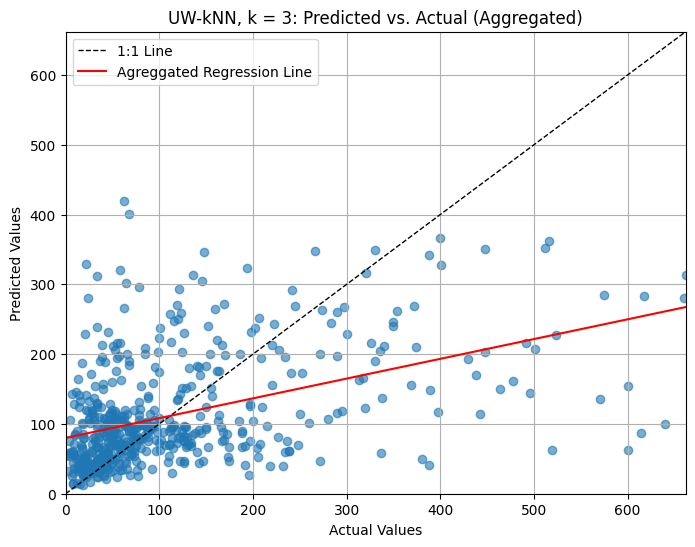


--- TRAIN SET METRICS (averaged across folds) ---
R²: 0.5441 ± 0.0338
RMSE: 83.7438 ± 3.1783 (mg/L)
NSE: 0.5441 ± 0.0338

--- TEST SET METRICS (averaged across folds) ---
R²: 0.0801 ± 0.0805
RMSE: 118.7794 ± 6.1078  (mg/L)
NSE: 0.0801 ± 0.0805


In [4]:
plot_results(
    apply_kNN(3, df[parameters], df[target], stratification),
    title= "UW-kNN, k = 3: Predicted vs. Actual (Aggregated)"
)

Como se vê, o resultado foi bastante inferior àquela apresentado no artigo original, onde as métricas de desempeho na fase de teste figuram como:

- R²: 0.36
- RMSE: 200 mg/L
- NSE: 0.34

A seguir buscamos encontrar um valor para k ótimo, mas nem após encontrá-lo conseguimos métricas comparáveis.

#### Buscando k ótimo

Testing k values from 1 to 100: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:07<00:00,  1.47it/s]


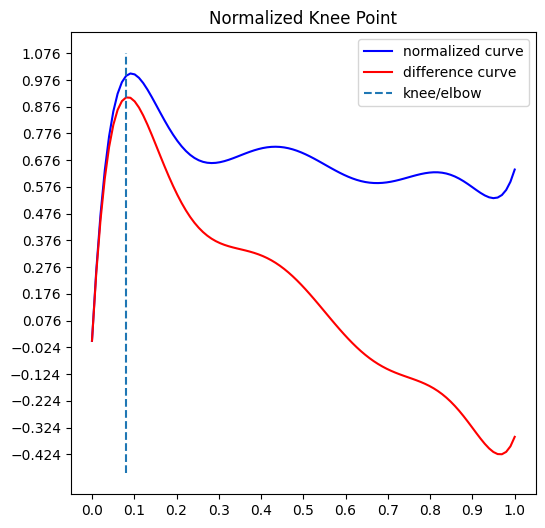

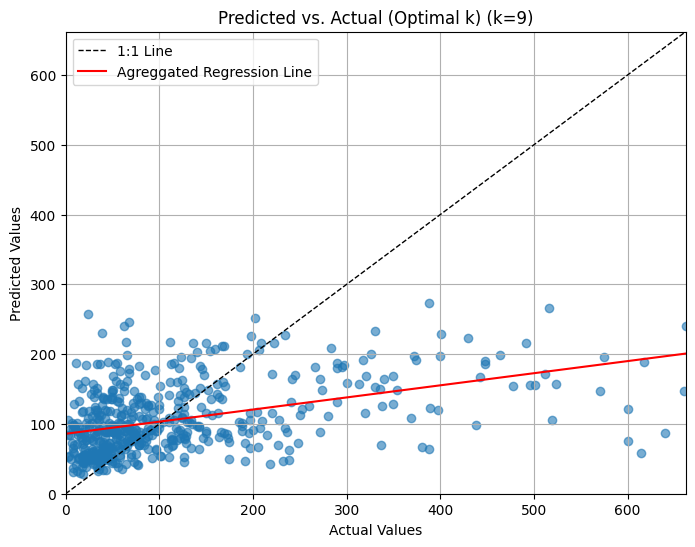


--- TRAIN SET METRICS (averaged across folds) ---
R²: 0.3170 ± 0.0205
RMSE: 102.5719 ± 2.4779 (mg/L)
NSE: 0.3170 ± 0.0205

--- TEST SET METRICS (averaged across folds) ---
R²: 0.1508 ± 0.0474
RMSE: 114.2429 ± 5.7024  (mg/L)
NSE: 0.1508 ± 0.0474


In [5]:
find_optimal_k_and_plot(df[parameters], df[target], stratification, range(1, 101))

### VW-kNN

#### Conforme artigo

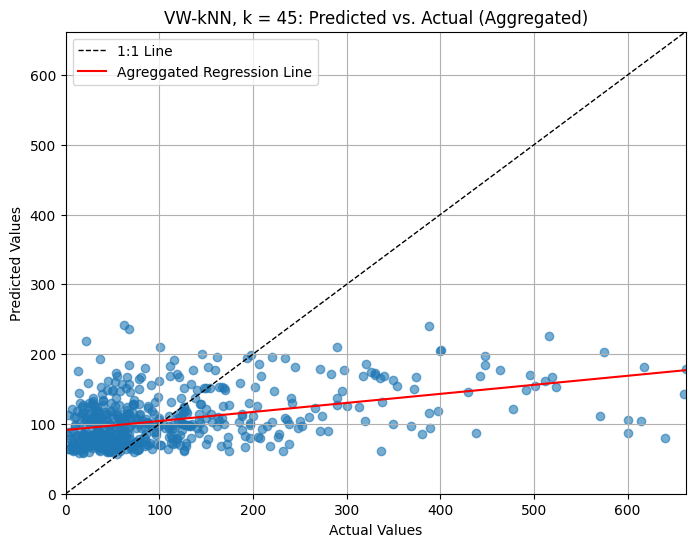


--- TRAIN SET METRICS (averaged across folds) ---
R²: 1.0000 ± 0.0000
RMSE: 0.0000 ± 0.0000 (mg/L)
NSE: 1.0000 ± 0.0000

--- TEST SET METRICS (averaged across folds) ---
R²: 0.1545 ± 0.0432
RMSE: 114.0195 ± 5.8923  (mg/L)
NSE: 0.1545 ± 0.0432


In [6]:
plot_results(
    apply_kNN(45, df[parameters], df[target], stratification, weighted=True),
    title= "VW-kNN, k = 45: Predicted vs. Actual (Aggregated)"
)

Vemos repetir um caso similar com o uso de pesos. Os autores do artigo citam as seguintes métricas de desempenho:
- R²: 0.56
- RMSE: 170 mg/L
- NSE: 0.55

#### Buscando k ótimo

Testing k values from 1 to 100: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:12<00:00,  1.38it/s]


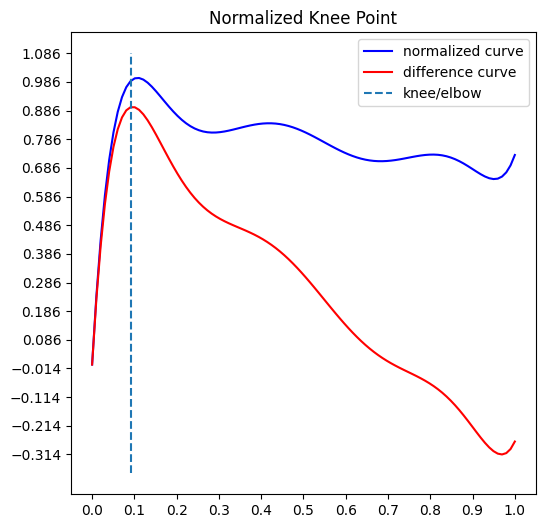

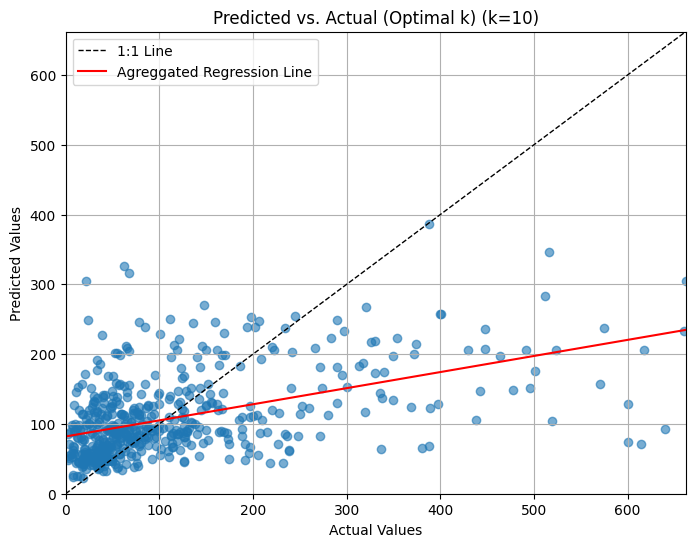


--- TRAIN SET METRICS (averaged across folds) ---
R²: 1.0000 ± 0.0000
RMSE: 0.0000 ± 0.0000 (mg/L)
NSE: 1.0000 ± 0.0000

--- TEST SET METRICS (averaged across folds) ---
R²: 0.1970 ± 0.0522
RMSE: 111.0659 ± 5.5551  (mg/L)
NSE: 0.1970 ± 0.0522


In [7]:
find_optimal_k_and_plot(df[parameters], df[target], stratification, range(1, 101), weighted=True)